# Tesla Delivery Analytics & Forecasting Pipeline

## Business Context

Tesla operates across multiple geographic markets and vehicle categories. Understanding the factors associated with vehicle deliveries can support production planning, resource allocation, infrastructure development, and demand forecasting

## Project Objectives

1. What operational and product-related variables are most strongly associated with Tesla delivery volumes?
2. How accurately can regression models estimate vehicle deliveries using operational and product-related features?
3. How does delivery performance vary across geographic markets?
4. Can historical delivery trends be leveraged to generate reliable future forecasts?

## Methodology

The analysis was conducted using the following workflow:

- Data Cleaning & Quality Checks
- Exploratory Data Analysis (EDA)
- Encoding & Feature Scaling
- Feature Engineering
- Linear, Ridge, and Lasso Regression
- Cross Validation and Model Evaluation
- Hyperparameter Tuning
- Stationarity Analysis (ADF Test)
- Time Series Decomposition
- ARIMA Forecasting
- Business Recommendations

**Target Variable:** `Estimated_Deliveries`

## 1. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

plt.style.use('default')
sns.set_theme()
pd.set_option('display.max_columns', None)

## 2. Data Loading

In [2]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print("Shape:", df.shape)
df.head()

Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 3. Data Understanding and Quality Assessment

In [3]:
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
count,2640.000000,2640.000000,2640,2640,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640,2640.000000
unique,NaN,NaN,4,5,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,Europe,Model S,NaN,NaN,NaN,NaN,NaN,NaN,Interpolated (Month),NaN
freq,NaN,NaN,660,528,NaN,NaN,NaN,NaN,NaN,NaN,884,NaN
mean,2020.000000,6.500000,NaN,NaN,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,NaN,8932.133712
std,3.162877,3.452707,NaN,NaN,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,NaN,3469.565883
min,2015.000000,1.000000,NaN,NaN,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,NaN,3002.000000
25%,2017.000000,3.750000,NaN,NaN,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,NaN,5897.750000
50%,2020.000000,6.500000,NaN,NaN,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,NaN,8901.500000
75%,2023.000000,9.250000,NaN,NaN,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,NaN,11938.000000


### Observations

- The dataset contains 2,640 observations and 12 features.
- No missing values are present across any of the columns.
- Numerical variables include delivery volume, production units, vehicle price, battery capacity, range, charging stations, and environmental impact metrics.
- Categorical variables include region, vehicle model, and source type.
- Delivery volumes range from 48 to 25,704 vehicles, indicating substantial variation across observations.
- The dataset spans the years 2015 to 2025, making it suitable for both regression and time-series analysis.

In [4]:
missing = df.isnull().sum()
duplicates = df.duplicated().sum()

print("Missing Values per Column:")
display(missing[missing > 0])
print("\nDuplicate Rows:", duplicates)

Missing Values per Column:


Series([], dtype: int64)


Duplicate Rows: 0


### Data Quality Assessment

The dataset does not contain any missing values or duplicate records. Therefore, no imputation or duplicate removal was required before proceeding with feature engineering and model development.

## 4. Feature Engineering

We construct temporal features (quarter, lag, rolling statistics) to capture delivery patterns over time.

In [5]:
df['Date'] = pd.to_datetime(dict(year=df['Year'], month=df['Month'], day=1))
df = df.sort_values('Date').reset_index(drop=True)

df['Quarter'] = df['Date'].dt.quarter

# Lag features
df['Lag_1_Deliveries'] = df['Estimated_Deliveries'].shift(1)
df['Lag_3_Deliveries'] = df['Estimated_Deliveries'].shift(3)

# Rolling statistics
df['Rolling_Mean_3'] = df['Estimated_Deliveries'].rolling(window=3).mean()
df['Rolling_STD_3']  = df['Estimated_Deliveries'].rolling(window=3).std()

df = df.dropna().reset_index(drop=True)
print("Dataset after feature engineering:", df.shape)
df.head()

Dataset after feature engineering: (2637, 18)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Lag_1_Deliveries,Lag_3_Deliveries,Rolling_Mean_3,Rolling_STD_3
0,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,1,8803.0,12446.0,8872.000000,2540.202945
1,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,1,6367.0,11446.0,7988.333333,1404.121552
2,2015,1,Europe,Cybertruck,2161,2465,112637.91,120,695,225.28,Estimated (Region),14062,2015-01-01,1,8795.0,8803.0,5774.333333,3356.475731
3,2015,1,North America,Model S,11986,13302,91906.09,82,457,821.64,Estimated (Region),4871,2015-01-01,1,2161.0,6367.0,7647.333333,5012.036545
4,2015,1,Europe,Model X,8833,8878,113652.43,82,461,610.80,Official (Quarter),10950,2015-01-01,1,11986.0,8795.0,7660.000000,5016.433295


### Feature Engineering Summary

Five new features were created:

- Quarter: captures seasonal variation across the year.
- Lag_1_Deliveries: previous observation of deliveries.
- Lag_3_Deliveries: deliveries from three periods earlier.
- Rolling_Mean_3: short-term moving average of deliveries.
- Rolling_STD_3: short-term variability in deliveries.

A small number of rows were removed because lagged and rolling features introduce missing values at the beginning of the time series.

## 5. Exploratory Data Analysis

### 5.1 Temporal Analysis of Delivery Volumes

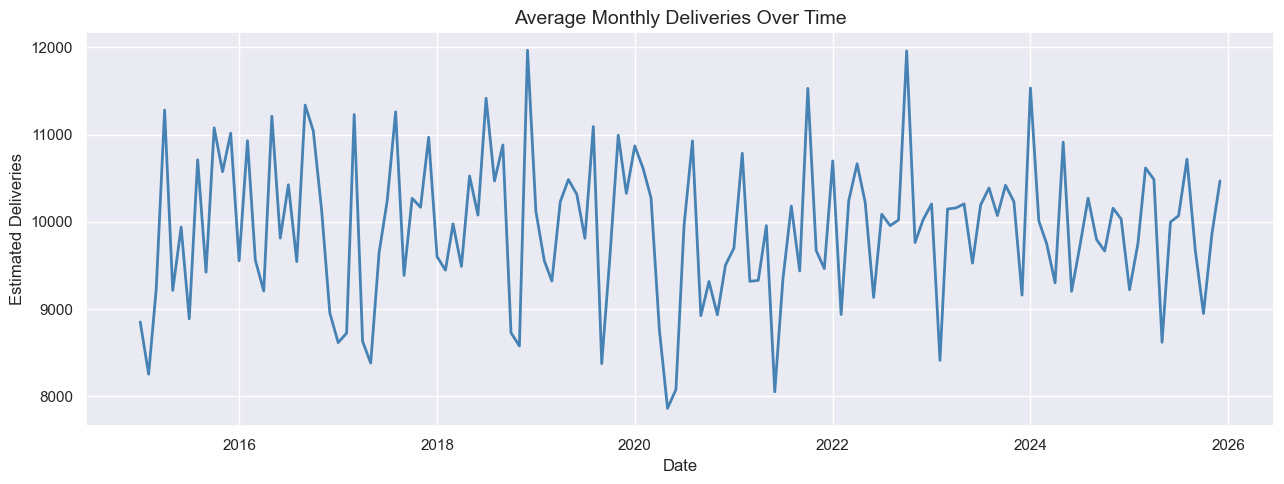

In [6]:
monthly = df.groupby('Date')['Estimated_Deliveries'].mean()

plt.figure(figsize=(13, 5))
plt.plot(monthly, color='steelblue', linewidth=2)
plt.title('Average Monthly Deliveries Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.tight_layout()
plt.show()

### Observations

- Average monthly deliveries fluctuate throughout the observation period.
- No strong long-term upward or downward trend is visible.
- Delivery volumes generally remain within a relatively stable range.
- Several short-term peaks and declines are observed, indicating temporal variability in demand.
- The absence of a strong deterministic trend suggests that operational and product-related features may play an important role in explaining delivery volume.

### 5.2 Distribution of Deliveries

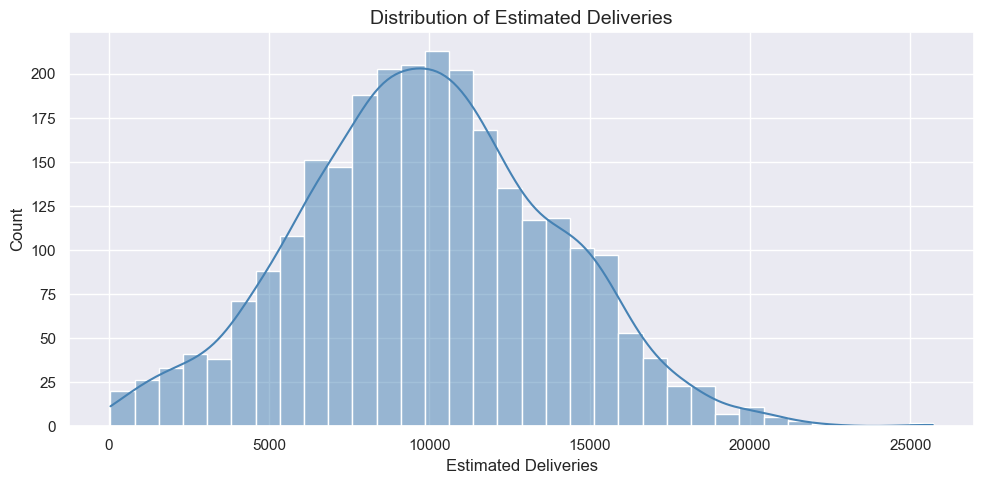

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Estimated_Deliveries'], kde=True, color='steelblue')
plt.title('Distribution of Estimated Deliveries', fontsize=14)
plt.xlabel('Estimated Deliveries')
plt.tight_layout()
plt.show()

### Observations

- Estimated deliveries are concentrated around the range of 9,000 to 11,000 vehicles.
- The distribution is approximately bell-shaped with a slight right skew.
- No severe outliers are visible, suggesting that the target variable is relatively stable.
- The absence of extreme skewness supports the use of regression-based models for prediction.

### 5.3 Deliveries by Vehicle Model

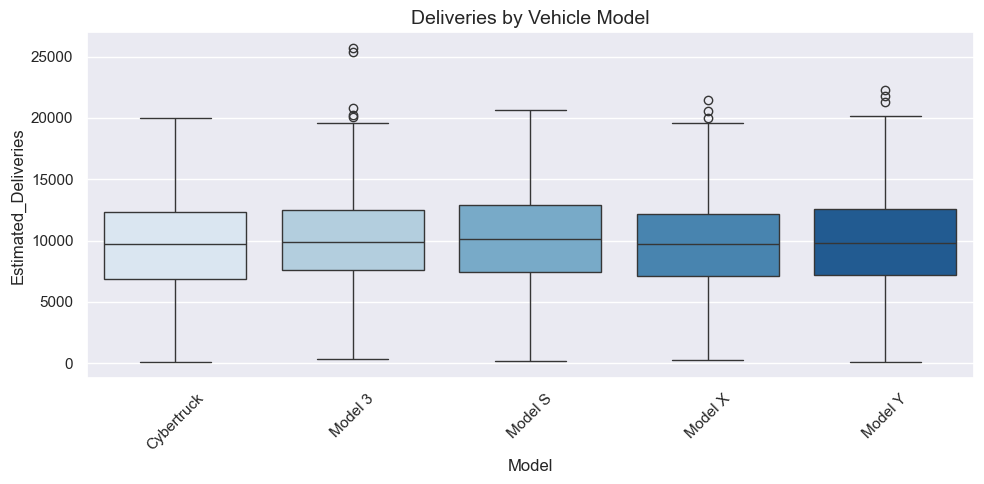

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Model', y='Estimated_Deliveries', data=df, palette='Blues')
plt.xticks(rotation=45)
plt.title('Deliveries by Vehicle Model', fontsize=14)
plt.tight_layout()
plt.show()

### Observations

- Delivery distributions are broadly similar across all vehicle models.
- Median delivery volumes do not differ substantially between models.
- Most models exhibit comparable variability, as indicated by similar interquartile ranges.
- A small number of high-delivery observations are present for several models, resulting in visible outliers.
- The similarity across distributions suggests that vehicle model alone may not fully explain variations in delivery volume.

### 5.4 Deliveries by Region

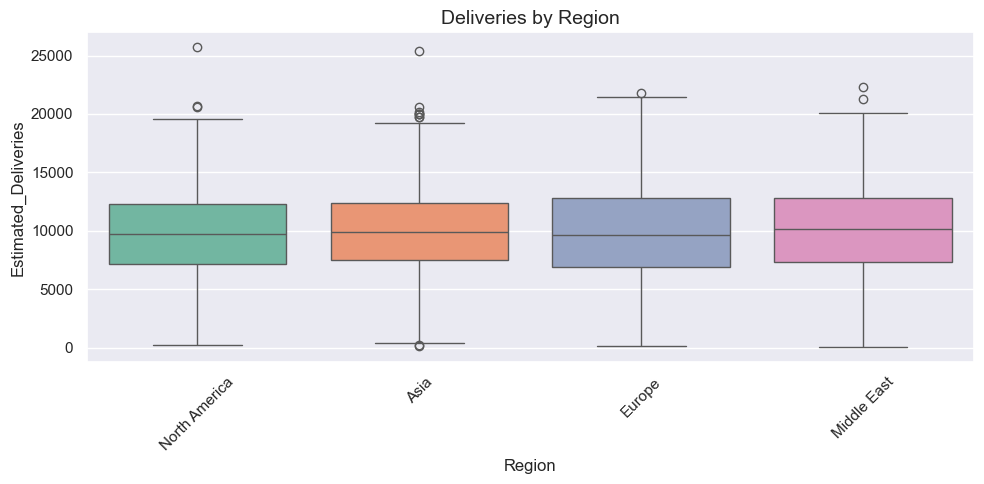

In [9]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Region', y='Estimated_Deliveries', data=df, palette='Set2')
plt.xticks(rotation=45)
plt.title('Deliveries by Region', fontsize=14)
plt.tight_layout()
plt.show()

### Observations

- Delivery distributions are broadly similar across all regions.
- Median delivery volumes show only minor variation between markets.
- The spread of deliveries is comparable across regions, indicating similar levels of variability.
- Several high-delivery observations are present across all regions.
- Based on this visualization alone, no single region appears to consistently outperform the others.

### 5.5 Correlation Matrix

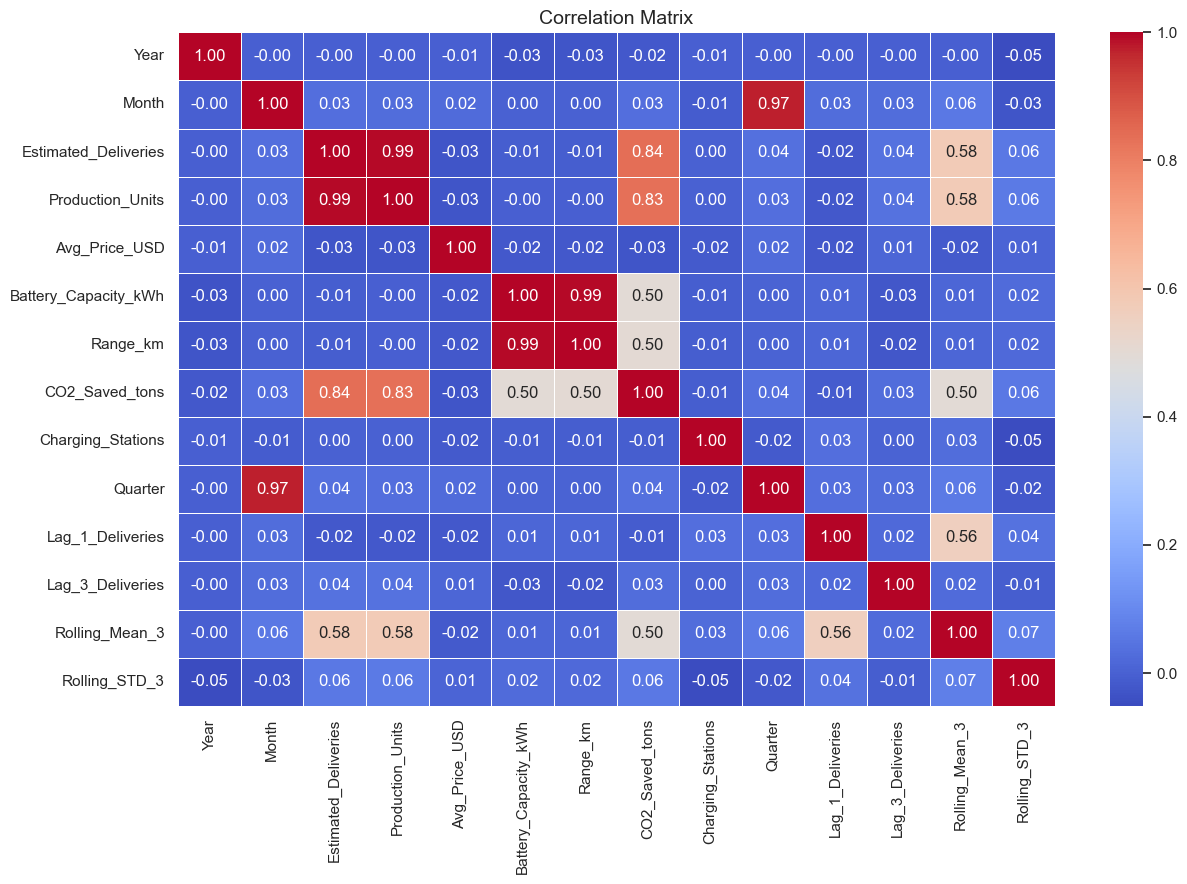

In [10]:
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(13, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

### Key EDA Observations

- Production Units exhibit an extremely strong positive correlation with Estimated Deliveries (0.99), suggesting that production capacity is a major driver of delivery volume.
- CO2_Saved_tons also shows a strong positive association with deliveries, indicating that higher delivery volumes correspond to greater environmental impact reductions.
- Rolling_Mean_3 demonstrates a moderate positive relationship with delivery volume, supporting the usefulness of temporal feature engineering.
- Battery Capacity and Range are highly correlated with each other (0.99), indicating potential multicollinearity between vehicle specification features.
- Most remaining variables show relatively weak linear relationships with the target variable.

## 6. Train-Test Split (Chronological)

In [11]:
features = [
    'Year', 'Month', 'Quarter',
    'Region', 'Model',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Source_Type',
    'Charging_Stations',
    'Lag_1_Deliveries',
    'Lag_3_Deliveries',
    'Rolling_Mean_3',
    'Rolling_STD_3'
]

target = 'Estimated_Deliveries'

X = df[features]
y = df[target]

split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 2109
Test samples: 528


### Train-Test Split Summary

A chronological train-test split was used to preserve the temporal order of observations. The first 80% of records were used for training, while the remaining 20% were reserved for testing. This approach better reflects real-world forecasting scenarios and helps prevent data leakage.

## 7. Preprocessing Pipeline

### Preprocessing Strategy

A preprocessing pipeline was constructed to ensure consistent treatment of numerical and categorical variables.

- Numerical features were imputed using the median and standardized using StandardScaler.
- Categorical features were imputed using the most frequent category and encoded using One-Hot Encoding.
- The pipeline was integrated into the modeling workflow to prevent data leakage and ensure reproducibility.

In [12]:
categorical = ['Region', 'Model', 'Source_Type']
numerical   = [c for c in X.columns if c not in categorical]

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ]), numerical),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical)
])

## 8. Regression Model Comparison

### Modeling Approach

Three regression models were evaluated to estimate vehicle deliveries. Linear Regression serves as the baseline model, while Ridge and Lasso Regression introduce regularization to reduce model complexity and improve generalization.

| Model | Description |
|---|---|
| **Linear Regression** | Baseline linear model |
| **Ridge Regression** | L2 regularization applied to coefficient estimates |
| **Lasso Regression** | L1 regularization with embedded feature selection |

### 8.1 Linear Regression

In [13]:
lr_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
pred_lr = lr_pipeline.predict(X_test)

mae_lr  = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr   = r2_score(y_test, pred_lr)

print(f"Linear Regression - MAE: {mae_lr:.2f} | RMSE: {rmse_lr:.2f} | R²: {r2_lr:.4f}")

Linear Regression - MAE: 322.99 | RMSE: 392.26 | R²: 0.9884


### Linear Regression Results

Linear Regression achieved strong predictive performance with a low prediction error and an R^2 value of 0.9884. This indicates that a large proportion of the variability in delivery volume can be explained by the selected features.

### 8.2 Ridge Regression (with Hyperparameter Tuning)

In [14]:
ridge_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', Ridge())
])

tscv = TimeSeriesSplit(n_splits=5)

ridge_params = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

ridge_grid = GridSearchCV(
    ridge_pipeline, ridge_params, cv=tscv, scoring='r2', n_jobs=-1
)
ridge_grid.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_grid.best_params_['model__alpha'])
print("Best CV R²:      ", round(ridge_grid.best_score_, 4))

pred_ridge = ridge_grid.best_estimator_.predict(X_test)

mae_ridge  = mean_absolute_error(y_test, pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))
r2_ridge   = r2_score(y_test, pred_ridge)

print(f"\nRidge Regression - MAE: {mae_ridge:.2f} | RMSE: {rmse_ridge:.2f} | R²: {r2_ridge:.4f}")

Best Ridge alpha: 0.01
Best CV R²:       0.9906

Ridge Regression - MAE: 322.98 | RMSE: 392.25 | R²: 0.9884


### Ridge Regression Results

TimeSeriesSplit cross-validation and GridSearchCV identified an optimal regularization parameter of alpha = 0.01.

The Ridge model achieved performance nearly identical to Linear Regression, indicating that only a minimal amount of regularization was required. This suggests that the dataset does not suffer from severe overfitting or instability in coefficient estimates.

### 8.3 Lasso Regression (with Hyperparameter Tuning)

In [15]:
lasso_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', Lasso(max_iter=10000))
])

lasso_params = {'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}

lasso_grid = GridSearchCV(
    lasso_pipeline, lasso_params, cv=tscv, scoring='r2', n_jobs=-1
)
lasso_grid.fit(X_train, y_train)

print("Best Lasso alpha:", lasso_grid.best_params_['model__alpha'])
print("Best CV R²:      ", round(lasso_grid.best_score_, 4))

pred_lasso = lasso_grid.best_estimator_.predict(X_test)

mae_lasso  = mean_absolute_error(y_test, pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, pred_lasso))
r2_lasso   = r2_score(y_test, pred_lasso)

print(f"\nLasso Regression - MAE: {mae_lasso:.2f} | RMSE: {rmse_lasso:.2f} | R²: {r2_lasso:.4f}")

Best Lasso alpha: 10.0
Best CV R²:       0.9909

Lasso Regression - MAE: 323.96 | RMSE: 393.17 | R²: 0.9884


### Lasso Regression Results

GridSearchCV identified an optimal regularization parameter of alpha = 10.0.

Although Lasso achieved strong predictive performance, its error metrics were slightly higher than those of Linear and Ridge Regression. This suggests that aggressive coefficient shrinkage did not improve predictive accuracy for this dataset.

The results indicate that most features contribute useful information and therefore extensive feature elimination is not beneficial.

### 8.4 Model Comparison Table

In [16]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'MAE':   [round(mae_lr, 2),  round(mae_ridge, 2),  round(mae_lasso, 2)],
    'RMSE':  [round(rmse_lr, 2), round(rmse_ridge, 2), round(rmse_lasso, 2)],
    'R²':    [round(r2_lr, 4),   round(r2_ridge, 4),   round(r2_lasso, 4)]
})

display(results)

,Model,MAE,RMSE,R²
0,Linear Regression,322.99,392.26,0.9884
1,Ridge Regression,322.98,392.25,0.9884
2,Lasso Regression,323.96,393.17,0.9884


### Model Comparison Summary

**Linear Regression provides the best balance of predictive performance and interpretability** on this dataset.

All three regression models achieved very similar performance, with R^2 values of approximately 0.9884 and low prediction errors.

Linear Regression was selected as the final model because it provides comparable predictive accuracy while remaining the simplest and most interpretable approach.

The minimal differences between Linear, Ridge, and Lasso Regression suggest that the dataset already exhibits a strong linear relationship between the predictor variables and delivery volume. As a result, additional regularization provides limited benefit.

> **Linear Regression is selected as the final model** for feature interpretation and residual analysis.

### 8.5 Actual vs Predicted - Linear Regression

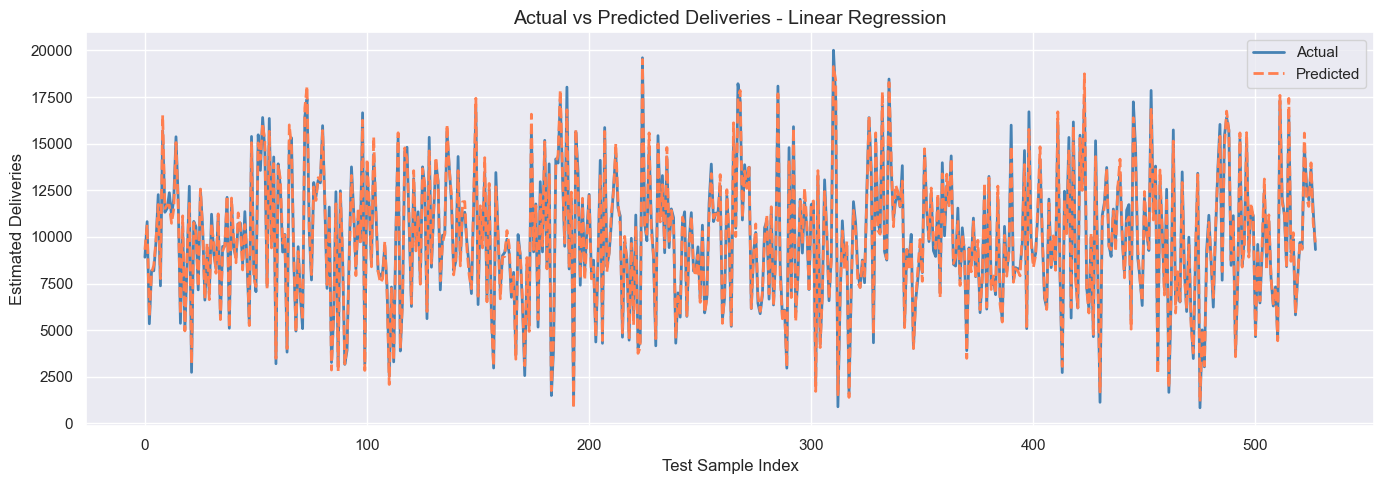

In [17]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.values, label='Actual',    color='steelblue', linewidth=2)
plt.plot(pred_lr,       label='Predicted', color='coral',     linewidth=2, linestyle='--')
plt.title('Actual vs Predicted Deliveries - Linear Regression', fontsize=14)
plt.xlabel('Test Sample Index')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

### Actual vs Predicted Analysis

The predicted delivery values closely follow the observed delivery values throughout the test period. The strong overlap between the two series indicates that the Linear Regression model successfully captures the underlying relationship between the predictor variables and delivery volume.

Only minor deviations are observed at certain peaks and troughs, which is consistent with the high R^2 score (0.9884) and low prediction error obtained during model evaluation.

### 8.6 Residual Analysis

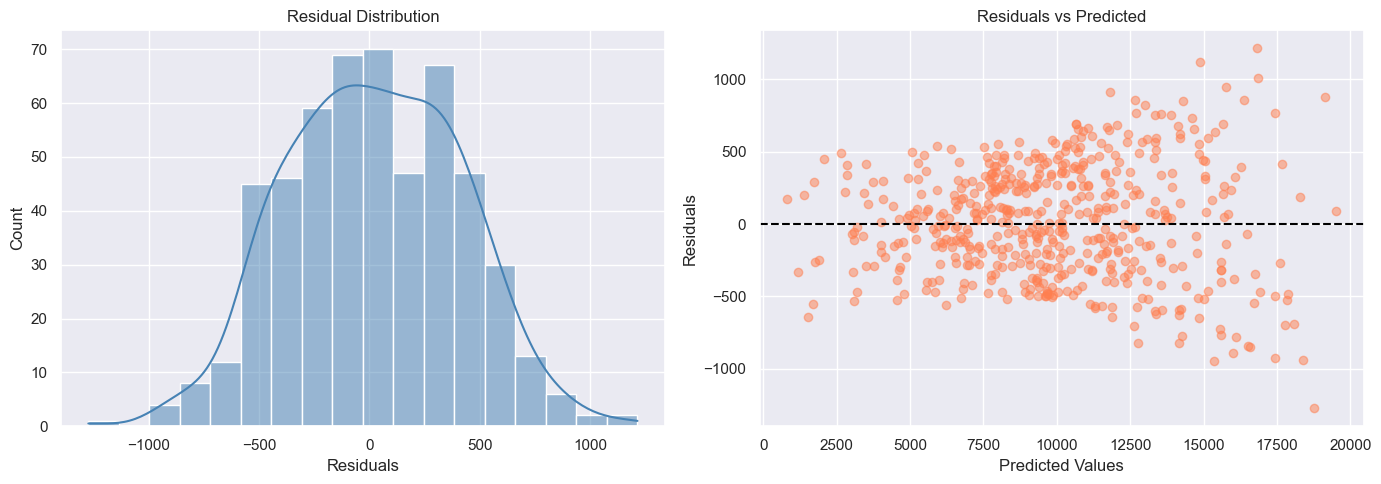

In [18]:
residuals = y_test - pred_lr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuals, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residuals')

axes[1].scatter(pred_lr, residuals, alpha=0.5, color='coral')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

### Residual Analysis

The residual distribution is approximately centered around zero and follows a reasonably symmetric shape, indicating that the model does not exhibit substantial systematic bias.

The residuals-versus-predicted plot shows no strong nonlinear patterns, suggesting that the linear regression assumptions are generally satisfied. Although a slight increase in residual spread is visible at higher prediction values, the overall residual behavior remains acceptable for predictive modeling purposes.

These observations support the suitability of Linear Regression for modeling delivery volumes in this dataset.

## 9. Feature Importance Analysis

To understand the factors most strongly associated with delivery volume, coefficient magnitudes from the final Linear Regression model were examined. Features were ranked according to the absolute value of their coefficients, with larger values indicating a stronger influence on the model's predictions.

In [19]:
# Extract feature names after preprocessing
lr_model = lr_pipeline.named_steps['model']
prep_step = lr_pipeline.named_steps['prep']

num_features = numerical
cat_features = list(
    prep_step.named_transformers_['cat']
             .named_steps['encoder']
             .get_feature_names_out(categorical)
)

all_features = num_features + cat_features

coef_df = pd.DataFrame({
    'Feature':     all_features,
    'Coefficient': lr_model.coef_
})

# Focus on the original numerical features for interpretability
num_coef_df = coef_df[coef_df['Feature'].isin(numerical)].copy()
num_coef_df['Abs_Coefficient'] = num_coef_df['Coefficient'].abs()
num_coef_df = num_coef_df.sort_values('Abs_Coefficient', ascending=False)

display(num_coef_df[['Feature', 'Coefficient', 'Abs_Coefficient']].reset_index(drop=True))

,Feature,Coefficient,Abs_Coefficient
0,Production_Units,3329.475049,3329.475049
1,CO2_Saved_tons,740.661864,740.661864
2,Range_km,-405.897637,405.897637
3,Rolling_Mean_3,58.424407,58.424407
4,Month,-40.863521,40.863521
5,Quarter,40.658688,40.658688
6,Lag_1_Deliveries,-31.060188,31.060188
7,Battery_Capacity_kWh,23.595589,23.595589
8,Rolling_STD_3,-7.914196,7.914196
9,Year,-4.740929,4.740929


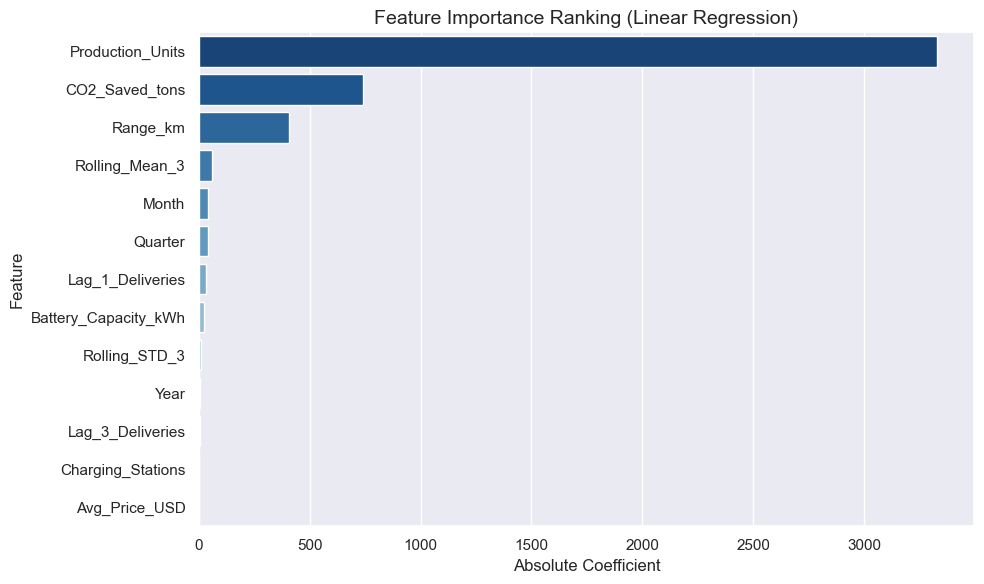

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=num_coef_df,
    x='Abs_Coefficient',
    y='Feature',
    palette='Blues_r'
)
plt.title('Feature Importance Ranking (Linear Regression)', fontsize=14)
plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Feature Importance Findings

| Feature | Business Interpretation |
|---|---|
| **Production_Units** | Manufacturing output is the strongest factor associated with delivery volume |
| **CO2_Saved_tons** | Higher environmental impact metrics are associated with stronger delivery performance |
| **Range_km** | Vehicles with greater driving range appear to be associated with higher delivery demand |
| **Rolling_Mean_3** | Recent delivery trends provide useful information about future delivery levels |
| **Remaining Features** | Price, charging infrastructure, battery capacity, and lag variables contribute additional information but have comparatively smaller influence |

> **Operational Insight:** Production volume emerged as the strongest predictor of delivery performance. Product characteristics such as vehicle range and broader adoption-related indicators also contribute meaningfully, while short-term delivery trends provide additional forecasting value.

## 10. Regional Delivery Performance Analysis

### Questions
- Which regions contribute the largest share of total deliveries?
- How do delivery patterns vary geographically?
- Which markets show the strongest operational performance?

### 10.1 Total Deliveries by Region

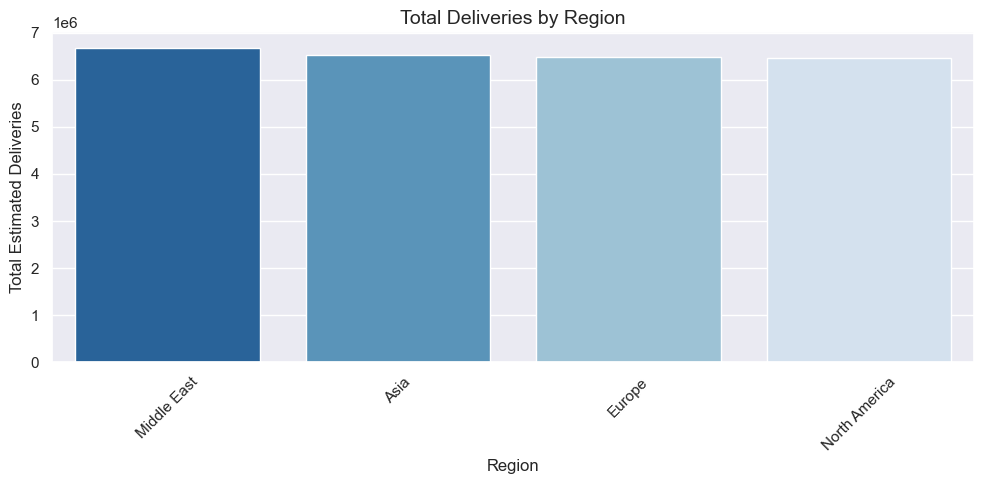

In [21]:
region_totals = (
    df.groupby('Region')['Estimated_Deliveries']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=region_totals, x='Region', y='Estimated_Deliveries', palette='Blues_r')
plt.title('Total Deliveries by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Total Estimated Deliveries')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Regional Delivery Findings

- Delivery volumes are distributed relatively evenly across all four regions.
- The Middle East records the highest cumulative delivery volume in the dataset.
- Asia and Europe closely follow, with only marginal differences from the leading region.
- North America contributes the lowest total deliveries, although the gap remains relatively small.
- Overall, regional delivery performance appears balanced rather than concentrated in a single market.

### 10.2 Deliveries by Model and Region

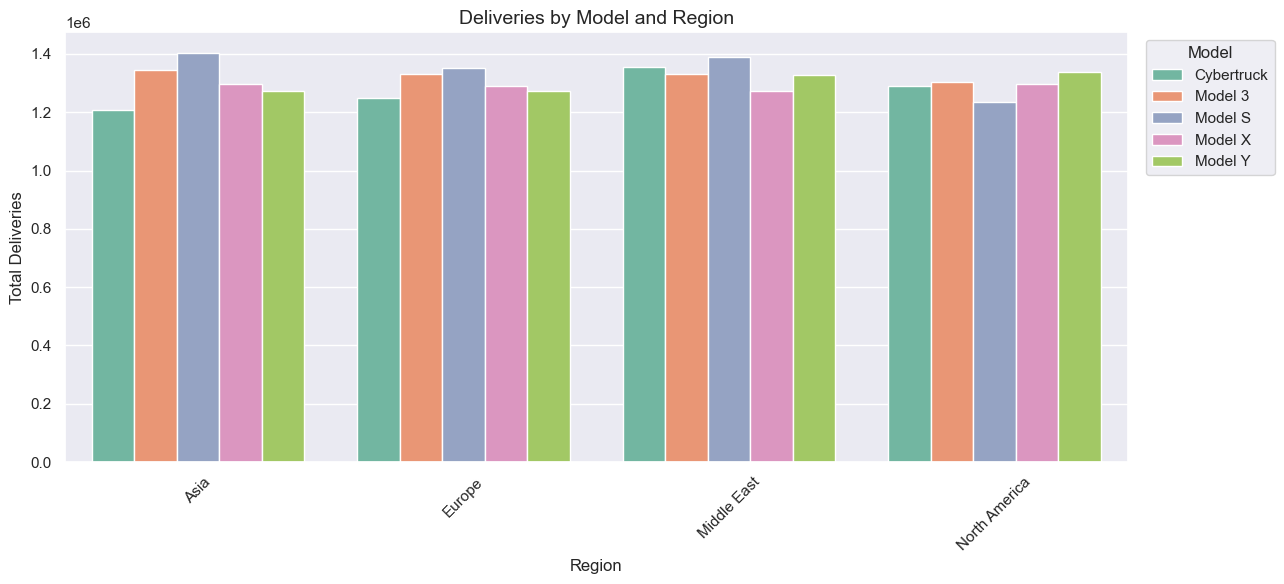

In [22]:
region_model = (
    df.groupby(['Region', 'Model'])['Estimated_Deliveries']
    .sum()
    .reset_index()
)

plt.figure(figsize=(13, 6))
sns.barplot(
    data=region_model, x='Region', y='Estimated_Deliveries',
    hue='Model', palette='Set2'
)
plt.title('Deliveries by Model and Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Total Deliveries')
plt.xticks(rotation=45)
plt.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Model and Region Findings

- Delivery volumes vary across vehicle models within each region.
- Model S records some of the highest delivery totals in Asia, Europe, and the Middle East.
- Model Y performs particularly well in North America and remains competitive across all regions.
- Cybertruck contributes comparatively lower delivery volumes across most markets.
- No single model consistently dominates every geographic region, suggesting a diversified product portfolio.

### 10.3 Regional Contribution Percentage

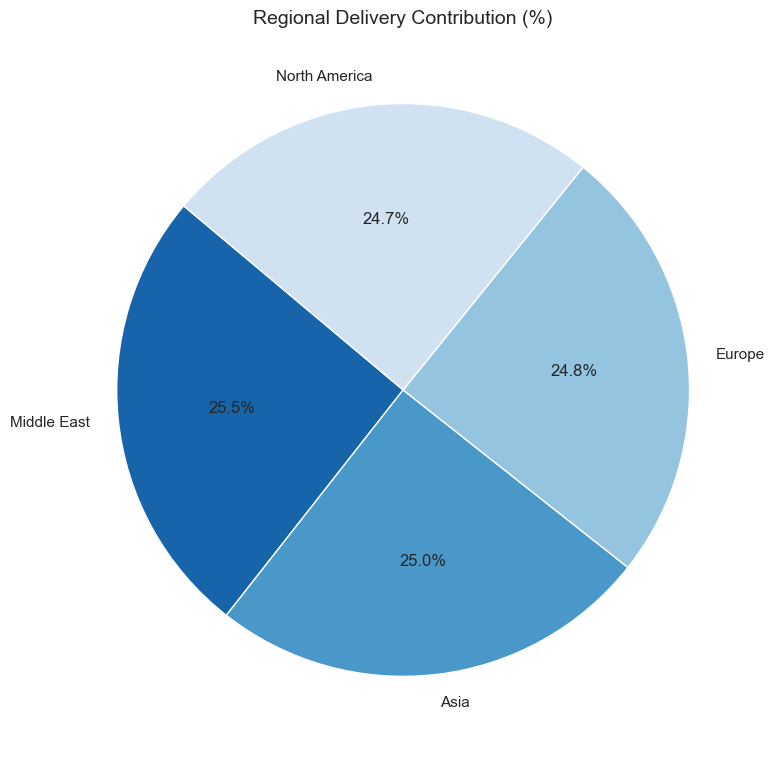

,Region,Estimated_Deliveries,Share_%
0,Middle East,6677796,25.52
1,Asia,6527489,24.95
2,Europe,6494035,24.82
3,North America,6462592,24.70


In [23]:
region_share = region_totals.copy()
region_share['Share_%'] = (
    region_share['Estimated_Deliveries'] /
    region_share['Estimated_Deliveries'].sum() * 100
).round(2)

plt.figure(figsize=(8, 8))
plt.pie(
    region_share['Share_%'],
    labels=region_share['Region'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Blues_r', len(region_share))
)
plt.title('Regional Delivery Contribution (%)', fontsize=14)
plt.tight_layout()
plt.show()

display(region_share)

### Regional Analysis Findings

- Regional delivery contributions are highly balanced across all four markets.
- The Middle East contributes the largest share of total deliveries (25.52%), although the difference from other regions is small.
- Asia, Europe, and North America each account for approximately one-quarter of overall deliveries.
- No region dominates total delivery volume, indicating a geographically diversified delivery network.

> **Business Insight:** The balanced regional contribution suggests that Tesla's delivery performance is not heavily dependent on a single market. Such diversification may help reduce geographic concentration risk and support more stable long-term operations.

## 11. Time Series Analysis

### 11.1 Aggregate Monthly Delivery Series

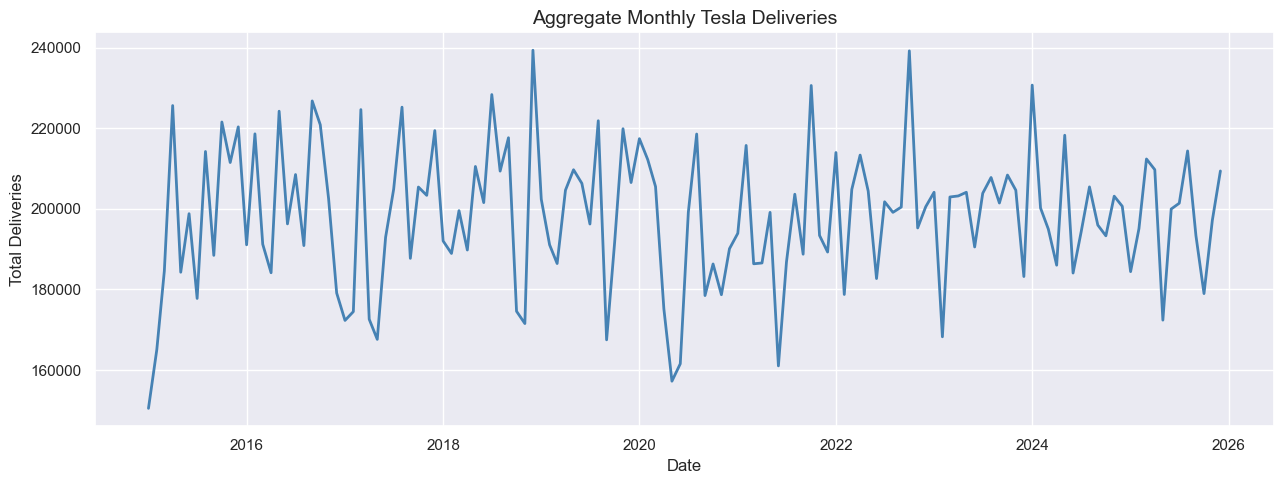

In [24]:
ts = df.groupby('Date')['Estimated_Deliveries'].sum().asfreq('MS')
ts = ts.ffill()

plt.figure(figsize=(13, 5))
plt.plot(ts, color='steelblue', linewidth=2)
plt.title('Aggregate Monthly Tesla Deliveries', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.tight_layout()
plt.show()

### Aggregate Monthly Delivery Series Findings

- Monthly Tesla deliveries fluctuate between approximately 150,000 and 240,000 units throughout the observation period.
- The series exhibits recurring peaks and troughs, suggesting the presence of seasonal or cyclical patterns.
- No strong long-term upward or downward trend is visually apparent in the aggregated series.
- Delivery volumes remain relatively stable around their central level, although short-term variability is observed across months.

> **Time-Series Insight:** The presence of recurring fluctuations indicates that temporal dependencies may exist in the data, supporting the use of lag features and time-series forecasting techniques in subsequent analysis.

### 11.2 Stationarity Check - ADF Test

In [25]:
def adf_test(series, title=''):
    result = adfuller(series.dropna())
    print(f'ADF Test: {title}')
    print(f'  Test Statistic : {result[0]:.4f}')
    print(f'  p-value        : {result[1]:.4f}')
    print('\nCritical Values:')
    for key, value in result[4].items():
        print(f' {key}: {value:.4f}')
    print("\n")
    if result[1] <= 0.05:
        print('Series is stationary (reject H0)')
    else:
        print('Series is non-stationary (fail to reject H0)')

adf_test(ts, title='Original Series')

ADF Test: Original Series
  Test Statistic : -8.9602
  p-value        : 0.0000

Critical Values:
 1%: -3.4817
 5%: -2.8840
 10%: -2.5788


Series is stationary (reject H0)


### 11.3 Time Series Decomposition

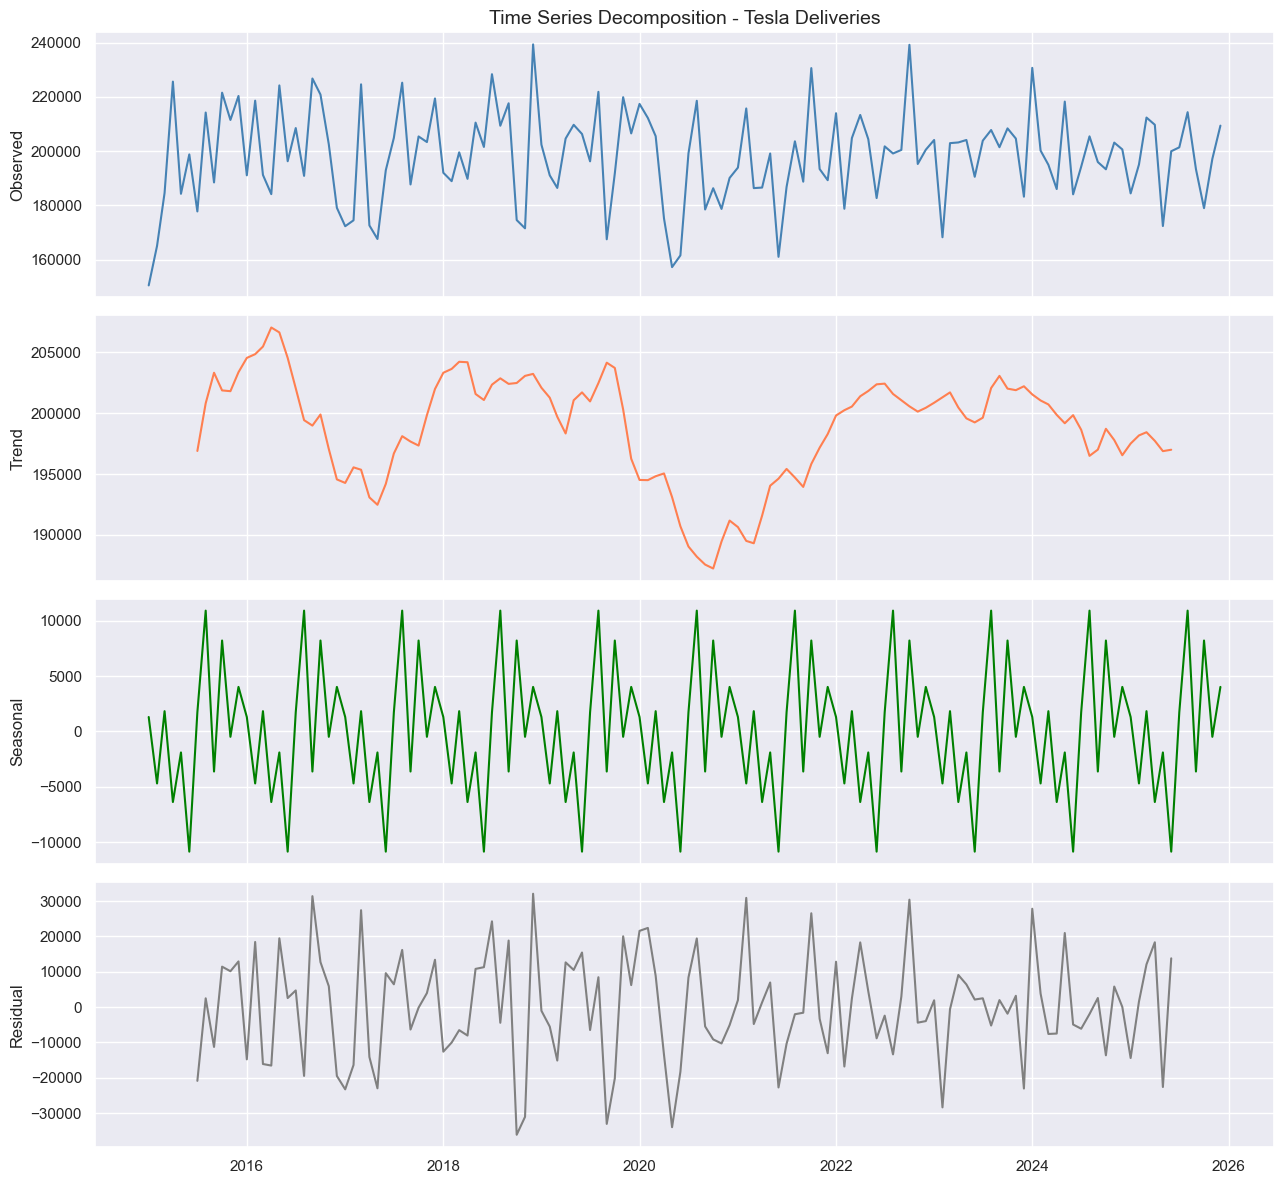

In [26]:
decomp = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)

axes[0].plot(decomp.observed,  color='steelblue'); axes[0].set_ylabel('Observed')
axes[1].plot(decomp.trend,     color='coral');     axes[1].set_ylabel('Trend')
axes[2].plot(decomp.seasonal,  color='green');     axes[2].set_ylabel('Seasonal')
axes[3].plot(decomp.resid,     color='grey');      axes[3].set_ylabel('Residual')

axes[0].set_title('Time Series Decomposition - Tesla Deliveries', fontsize=14)
plt.tight_layout()
plt.show()

### Decomposition Insights

| Component | Observation |
|---|---|
| **Trend** | Long-term delivery levels fluctuate over time, showing periods of growth, decline, and recovery across the study period |
| **Seasonality** | A recurring seasonal pattern is visible, indicating regular fluctuations in delivery volumes throughout the year |
| **Residual** | Residual variation captures unexplained fluctuations not accounted for by trend and seasonality |

### 11.4 ARIMA Forecasting

In [27]:
# Train/Test split - hold out last 12 months
train_ts = ts.iloc[:-12]
test_ts  = ts.iloc[-12:]

print(f"Training months : {len(train_ts)}")
print(f"Test months     : {len(test_ts)}")

Training months : 120
Test months     : 12


In [28]:
# ARIMA forecasting model
arima_model = ARIMA(train_ts, order=(1, 0, 1))
arima_result = arima_model.fit()

print("AIC :", round(arima_result.aic, 2))
print("BIC :", round(arima_result.bic, 2))

AIC : 2695.42
BIC : 2706.57


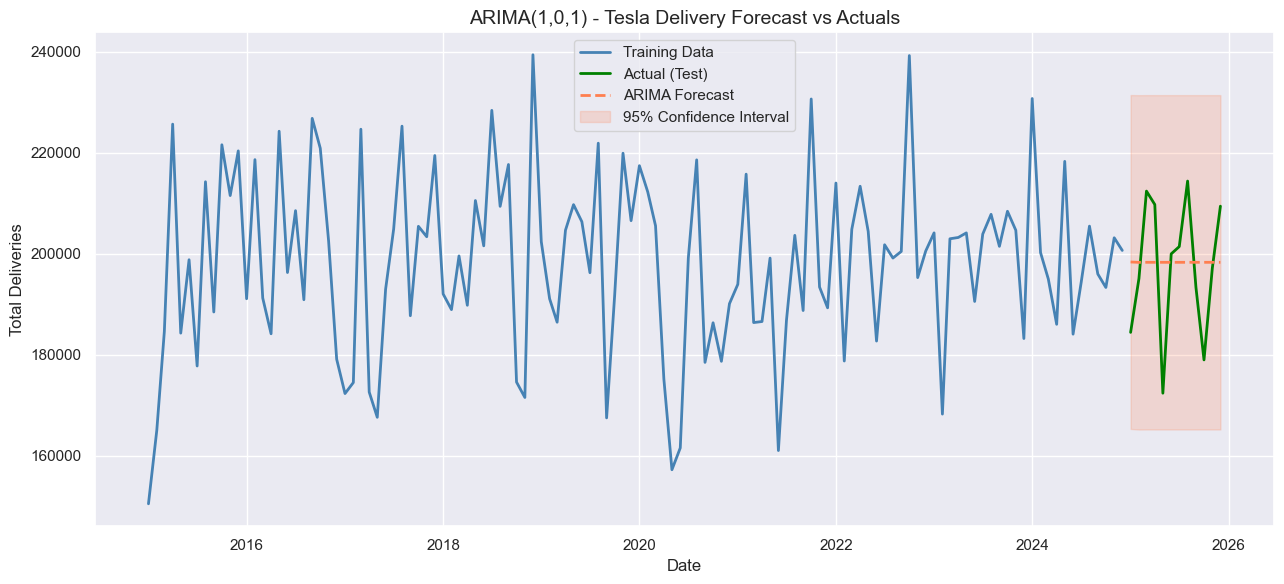

In [29]:
# Generate forecast over the test horizon
forecast_obj = arima_result.get_forecast(steps=12)
forecast     = forecast_obj.predicted_mean
conf_int     = forecast_obj.conf_int()

# Plot
plt.figure(figsize=(13, 6))
plt.plot(train_ts, label='Training Data',   color='steelblue', linewidth=2)
plt.plot(test_ts,  label='Actual (Test)',   color='green',     linewidth=2)
plt.plot(forecast, label='ARIMA Forecast',  color='coral',     linewidth=2, linestyle='--')
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.2, color='coral', label='95% Confidence Interval'
)
plt.title('ARIMA(1,0,1) - Tesla Delivery Forecast vs Actuals', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

### 11.5 ARIMA Forecast Evaluation

In [30]:
arima_mae  = mean_absolute_error(test_ts, forecast)
arima_rmse = np.sqrt(mean_squared_error(test_ts, forecast))

print(f"ARIMA Forecast - MAE : {arima_mae:.2f}")
print(f"ARIMA Forecast - RMSE: {arima_rmse:.2f}")

ARIMA Forecast - MAE : 10493.70
ARIMA Forecast - RMSE: 12902.43


### ARIMA Findings

- ARIMA captures the overall delivery level and broad temporal dynamics of the series.
- The forecast confidence interval quantifies uncertainty around future delivery estimates.
- MAE and RMSE provide a quantitative benchmark for forecast accuracy.

> **Key Insight:** ARIMA provides a simple and interpretable baseline forecasting model for Tesla delivery volumes. More advanced approaches, such as SARIMA or models incorporating additional explanatory variables, may improve predictive performance.

## 12. Executive Summary

### Key Findings

1. Production volume emerged as the strongest predictor of delivery volume, while recent delivery trends provided additional forecasting information.
2. Linear Regression achieved the best predictive performance among the evaluated regression models.
3. Regional analysis indicates relatively balanced delivery contributions across regions, with only modest differences in cumulative delivery volume.
4. ARIMA forecasting captured the overall delivery level and temporal dynamics of the series, providing a useful baseline for short-term forecasting.

### Business Impact

| Area | Recommendation |
|---|---|
| **Production Planning** | Closely align production schedules with delivery forecasts - production volume is the single most predictive variable |
| **Inventory Allocation** | Maintain balanced inventory allocation across regions while monitoring emerging changes in regional demand patterns. |
| **Infrastructure** | Monitor infrastructure-related indicators when evaluating regional delivery performance and future market expansion opportunities. |
| **Pricing Strategy** | Continue monitoring pricing trends, as average vehicle price demonstrated a measurable relationship with delivery outcomes. |
| **Forecasting Cadence** | Periodically retrain forecasting models as new delivery data becomes available. |